# DQN Highway — Episode Visualisation
**Before vs After Training**

This notebook loads a saved checkpoint and renders full episodes as frame-by-frame animations.
- **Untrained agent**: random weights (ε = 1.0, pure random)
- **Trained agent**: loaded from a choosed checkpoint (ε = 0, greedy)


## 0 — Setup

In [14]:
import sys, os, random
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML, display
import torch
import torch.nn as nn
import gymnasium as gym
import highway_env


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


## 1 — Environment Config

In [15]:
SHARED_CORE_ENV_ID = "highway-v0"

SHARED_CORE_CONFIG = {
    "observation": {
        "type": "Kinematics",
        "vehicles_count": 10,
        "features": ["presence", "x", "y", "vx", "vy"],
        "absolute": False,
        "normalize": True,
        "clip": True,
        "see_behind": True,
        "observe_intentions": False,
    },
    "action": {
        "type": "DiscreteMetaAction",
        "target_speeds": [20, 25, 30],
    },
    "lanes_count": 4,
    "vehicles_count": 45,
    "controlled_vehicles": 1,
    "initial_lane_id": None,
    "duration": 60,
    "ego_spacing": 2,
    "vehicles_density": 1.0,
    "collision_reward": -1.5,
    "right_lane_reward": 0.0,
    "high_speed_reward": 0.7,
    "lane_change_reward": -0.02,
    "reward_speed_range": [22, 30],
    "normalize_reward": True,
    "offroad_terminal": True,
    # render config
    "screen_width": 800,
    "screen_height": 200,
    "centering_position": [0.3, 0.5],
    "scaling": 6,
    "show_trajectories": False,
}

DENSE_BASELINE_CONFIG = {
    **SHARED_CORE_CONFIG,
    "vehicles_density": 2.0,
}

DENSE_BALANCED_CONFIG = {
    **SHARED_CORE_CONFIG,
    "vehicles_density": 2.0,
    "collision_reward": -3.0,
    "high_speed_reward": 0.45,
    "lane_change_reward": -0.05,
}

DENSE_SAFETY_CONFIG = {
    **SHARED_CORE_CONFIG,
    "vehicles_density": 2.0,
    "collision_reward": -5.0,
    "high_speed_reward": 0.25,
    "lane_change_reward": -0.08,
}

def make_env(config=None, render_mode="rgb_array"):
    env = gym.make(SHARED_CORE_ENV_ID, render_mode=render_mode)
    if config:
        env.unwrapped.config.update(config)
    return env

# Quick check
env_tmp = make_env(SHARED_CORE_CONFIG)
obs, _ = env_tmp.reset()
OBS_SIZE  = obs.flatten().shape[0]
N_ACTIONS = env_tmp.action_space.n
env_tmp.close()
print(f"OBS_SIZE={OBS_SIZE}, N_ACTIONS={N_ACTIONS}")


OBS_SIZE=50, N_ACTIONS=5


## 2 — Model Architecture

In [16]:
class QNet(nn.Module):
    def __init__(self, obs_size, n_actions, hidden_size=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, n_actions),
        )

    def forward(self, x):
        return self.net(x)

def greedy_action(q_net, obs, device):
    """Pick the greedy action from a QNet given a numpy obs."""
    state_t = torch.FloatTensor(obs.flatten()).unsqueeze(0).to(device)
    with torch.no_grad():
        q_values = q_net(state_t)
    return q_values.argmax(dim=1).item()


## 3 — Load Checkpoint

In [17]:
CHECKPOINT_PATH = "checkpoints/dqn_dense_baseline.pt" 

trained_net = QNet(OBS_SIZE, N_ACTIONS, hidden_size=128).to(device)
trained_net.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
trained_net.eval()

untrained_net = QNet(OBS_SIZE, N_ACTIONS, hidden_size=128).to(device)
untrained_net.eval()

print(f"Loaded checkpoint: {CHECKPOINT_PATH}")

Loaded checkpoint: checkpoints/dqn_dense_baseline.pt


## 4 — Rollout Helper

In [18]:
ACTION_LABELS = {0: "LANE_LEFT", 1: "IDLE", 2: "LANE_RIGHT", 3: "FASTER", 4: "SLOWER"}

def run_episode(q_net, config, seed=42, epsilon=0.0, device=device):
    env = make_env(config, render_mode="rgb_array")
    env.reset(seed=seed)
    env.step(env.action_space.sample())
    obs, _ = env.reset(seed=seed)

    def get_frame(env):
        return env.render()

    frames, actions, rewards = [], [], []
    done = False

    while not done:
        action = env.action_space.sample() if random.random() < epsilon else greedy_action(q_net, obs, device)
        print(action)
        obs, r, terminated, truncated, _ = env.step(action)
        frame = get_frame(env)
        if frame is not None:
            frames.append(frame)
            actions.append(action)
            rewards.append(r)
        done = terminated or truncated

    env.close()

    if not frames:
        raise RuntimeError(
            f"All 3 render strategies failed. "
            f"highway_env={highway_env.__version__}. "
            f"Run the diagnostic cell above and share the output."
        )

    return frames, actions, rewards, terminated


## 5 — Run Episodes

In [19]:
ROLLOUT_CONFIG = DENSE_BASELINE_CONFIG 
SEED = 42

print("Running UNTRAINED episode...")
frames_before, actions_before, rewards_before, crashed_before = run_episode(
    untrained_net, ROLLOUT_CONFIG, seed=SEED, epsilon=1.0
)

print("Running TRAINED episode...")
frames_after, actions_after, rewards_after, crashed_after = run_episode(
    trained_net, ROLLOUT_CONFIG, seed=SEED, epsilon=0.0
)

Running UNTRAINED episode...
4
1
3
4
2
1
2
1
3
3
Running TRAINED episode...
4
4
4
4
0
4
0
4
4
4
0
0
0
4
4
0
4
4
1
0
3
4
2
3
3


## 6 — Animate Episodes

In [20]:
def make_animation(frames, actions, rewards, title, fps=10):
    """Return an HTML5 video animation."""
    if not frames:
        raise ValueError(f"No frames to animate for '{title}'. Re-run cell 5.")

    fig, ax = plt.subplots(figsize=(10, 2.8))
    ax.axis("off")
    img_obj = ax.imshow(frames[0])

    cumulative = np.cumsum(rewards)
    title_obj = ax.set_title("", fontsize=11)

    def update(i):
        img_obj.set_data(frames[i])
        action_label = ACTION_LABELS.get(actions[i], str(actions[i])) if i < len(actions) else "-"
        title_obj.set_text(
            f"{title}   |   step {i+1}/{len(frames)}   "
            f"|   action: {action_label}   "
            f"|   step_r: {rewards[i]:.3f}   "
            f"|   cum_r: {cumulative[i]:.3f}"
        )
        return img_obj, title_obj

    ani = animation.FuncAnimation(
        fig, update, frames=len(frames), interval=1000 // fps, blit=True
    )
    plt.close(fig)
    return ani


### 6.1 — Untrained Agent (random policy)

In [21]:
ani_before = make_animation(
    frames_before, actions_before, rewards_before,
    title="UNTRAINED (ε=1.0)", fps=10
)
HTML(ani_before.to_jshtml())


### 6.2 — Trained Agent (greedy, ε=0)

In [22]:
ani_after = make_animation(
    frames_after, actions_after, rewards_after,
    title="TRAINED (ε=0)", fps=10
)
HTML(ani_after.to_jshtml())


## 7 — Side-by-Side Comparison

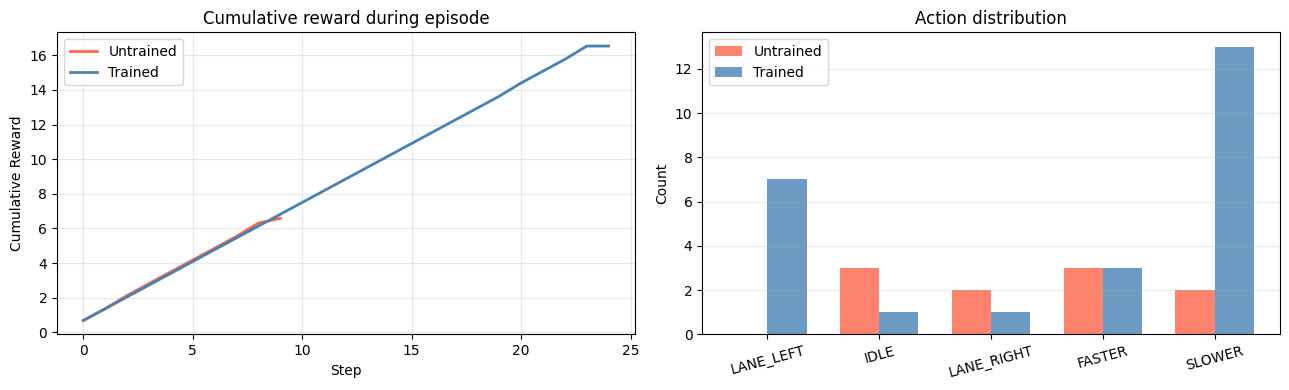

                        Untrained      Trained
----------------------------------------------
Total reward                6.586       16.535
Steps survived                 10           25
Crashed                       YES          YES
Mean step reward            0.659        0.661


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Cumulative reward over time
ax = axes[0]
ax.plot(np.cumsum(rewards_before), color='tomato',    lw=2, label='Untrained')
ax.plot(np.cumsum(rewards_after),  color='steelblue', lw=2, label='Trained')
ax.set_xlabel('Step')
ax.set_ylabel('Cumulative Reward')
ax.set_title('Cumulative reward during episode')
ax.legend()
ax.grid(alpha=0.3)

# Action distributions
ax = axes[1]
n_act = N_ACTIONS
labels = [ACTION_LABELS.get(i, str(i)) for i in range(n_act)]
x = np.arange(n_act)
w = 0.35
counts_before = np.bincount(actions_before, minlength=n_act)
counts_after  = np.bincount(actions_after,  minlength=n_act)
ax.bar(x - w/2, counts_before, w, color='tomato',    alpha=0.8, label='Untrained')
ax.bar(x + w/2, counts_after,  w, color='steelblue', alpha=0.8, label='Trained')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel('Count')
ax.set_title('Action distribution')
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('before_after_comparison.png', dpi=120)
plt.show()

# Summary table
print(f"{'':20} {'Untrained':>12} {'Trained':>12}")
print("-" * 46)
print(f"{'Total reward':<20} {sum(rewards_before):>12.3f} {sum(rewards_after):>12.3f}")
print(f"{'Steps survived':<20} {len(frames_before):>12d} {len(frames_after):>12d}")
print(f"{'Crashed':<20} {'YES' if crashed_before else 'NO':>12} {'YES' if crashed_after else 'NO':>12}")
print(f"{'Mean step reward':<20} {np.mean(rewards_before):>12.3f} {np.mean(rewards_after):>12.3f}")
